In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [25]:
df = pd.read_csv('Housing.csv')

In [26]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [28]:
df.shape


(20640, 10)

In [29]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

X = df.drop(['median_house_value'], axis=1)
y = df['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns
num_cols = X_train.select_dtypes(exclude=['object', 'category']).columns
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=np.nan, encoded_missing_value=np.nan)
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

if len(cat_cols) > 0:
    X_train_encoded[cat_cols] = encoder.fit_transform(X_train[cat_cols])
    X_test_encoded[cat_cols] = encoder.transform(X_test[cat_cols])

mice_imputer = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=15, random_state=42, max_depth=10), 
    max_iter=10, 
    random_state=42,
    verbose=0
)
X_train_imputed = pd.DataFrame(mice_imputer.fit_transform(X_train_encoded), columns=X_train.columns)
X_test_imputed = pd.DataFrame(mice_imputer.transform(X_test_encoded), columns=X_test.columns)

for df_imputed in [X_train_imputed, X_test_imputed]:
    if len(cat_cols) > 0:
        for idx, col in enumerate(cat_cols):
            df_imputed[col] = df_imputed[col].round().astype(int)
            max_val = len(encoder.categories_[idx]) - 1
            df_imputed[col] = df_imputed[col].clip(0, max_val)
        df_imputed[cat_cols] = encoder.inverse_transform(df_imputed[cat_cols])

X_train_imputed['median_house_value'] = y_train.values
X_test_imputed['median_house_value'] = y_test.values
df = pd.concat([X_train_imputed, X_test_imputed], axis=0).reset_index(drop=True)


Text(0.5, 1.0, 'Distribution of Median House Value')

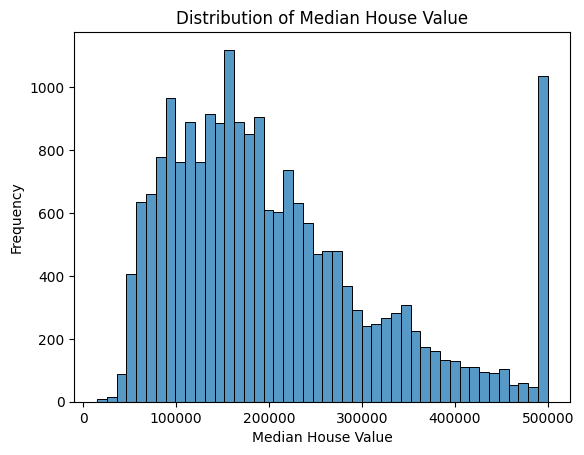

In [32]:
sns.histplot(df['median_house_value'])
plt.xlabel('Median House Value')
plt.ylabel('Frequency')
plt.title('Distribution of Median House Value')

In [33]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(['longitude', 'latitude'])
categorical_cols = df.select_dtypes(include=['object'])

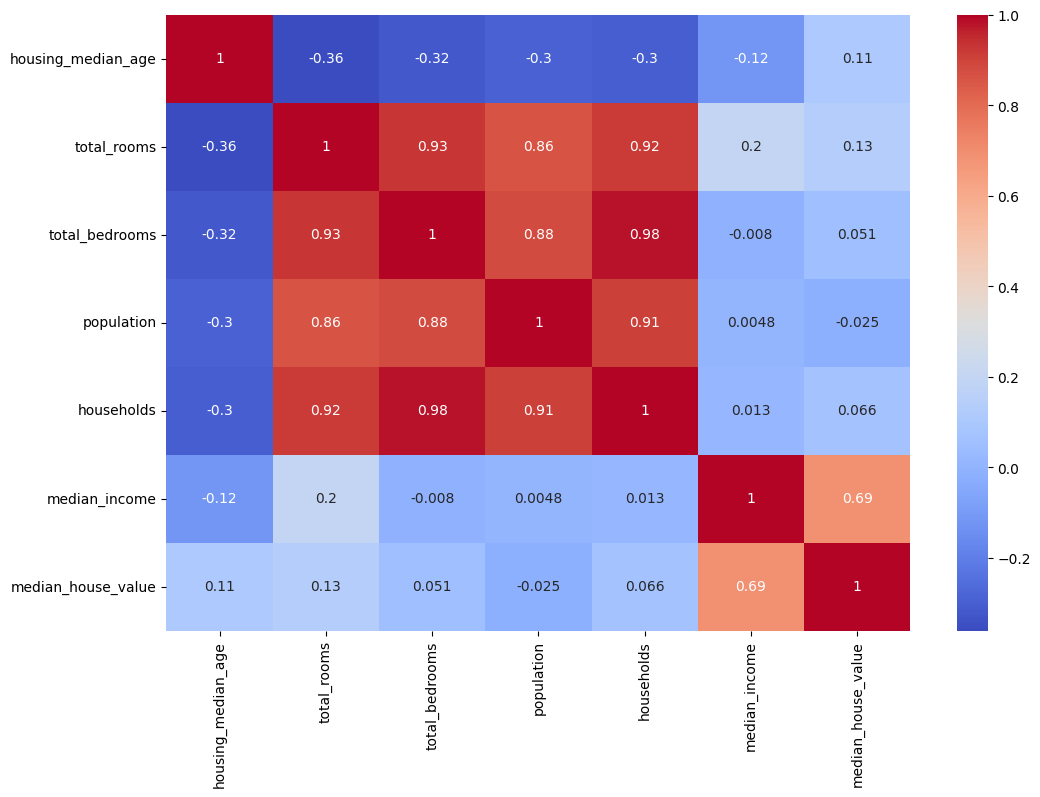

In [34]:
correlation_matrix = df[numeric_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

In [35]:
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_household'] = df['total_bedrooms'] / df['households']
df['population_per_household'] = df['population'] / df['households']
df = df.drop(['total_rooms', 'total_bedrooms', 'population', 'households'], axis=1)

In [36]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
log_transform_cols = []
zero_threshold = 0.75
for col in numeric_cols:
    value_counts = df[col].value_counts(normalize=True)
    if 0 in value_counts.index and value_counts[0] > zero_threshold:
        continue
    skewness = df[col].skew()
    if abs(skewness) > 0.5:
        log_transform_cols.append(col)
        print(f"Column: {col}, Skewness: {skewness:.2f}")
print(log_transform_cols)

Column: median_income, Skewness: 1.65
Column: median_house_value, Skewness: 0.98
Column: bedrooms_per_room, Skewness: 2.24
Column: rooms_per_household, Skewness: 20.70
Column: bedrooms_per_household, Skewness: 31.33
Column: population_per_household, Skewness: 97.64
['median_income', 'median_house_value', 'bedrooms_per_room', 'rooms_per_household', 'bedrooms_per_household', 'population_per_household']


Column: median_income, Lower Bound: -0.71, Upper Bound: 8.01
count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64
median_income: 3.3


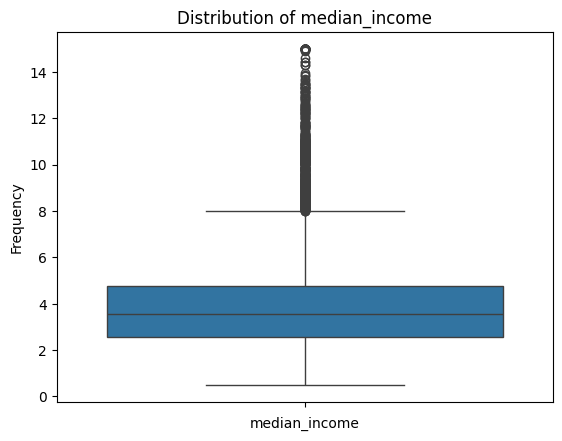

Column: median_house_value, Lower Bound: -98087.50, Upper Bound: 482412.50
count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64
median_house_value: 5.19


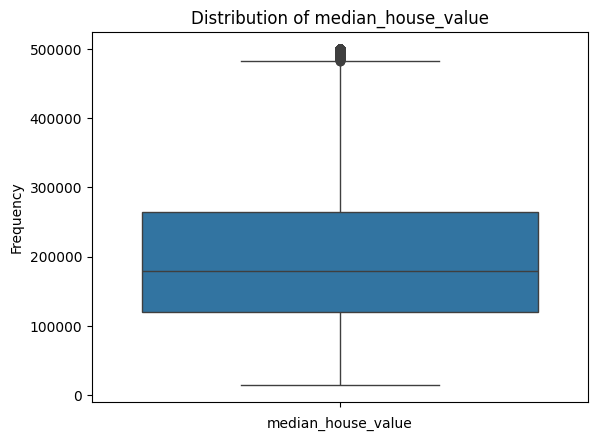

Column: bedrooms_per_room, Lower Bound: 0.08, Upper Bound: 0.34
count    20640.000000
mean         0.213111
std          0.058027
min          0.100000
25%          0.175439
50%          0.203224
75%          0.239840
max          1.000000
Name: bedrooms_per_room, dtype: float64
bedrooms_per_room: 2.87


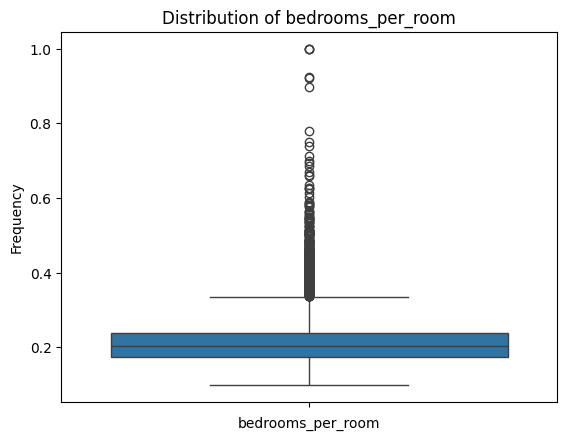

Column: rooms_per_household, Lower Bound: 2.02, Upper Bound: 8.47
count    20640.000000
mean         5.429000
std          2.474173
min          0.846154
25%          4.440716
50%          5.229129
75%          6.052381
max        141.909091
Name: rooms_per_household, dtype: float64
rooms_per_household: 2.26


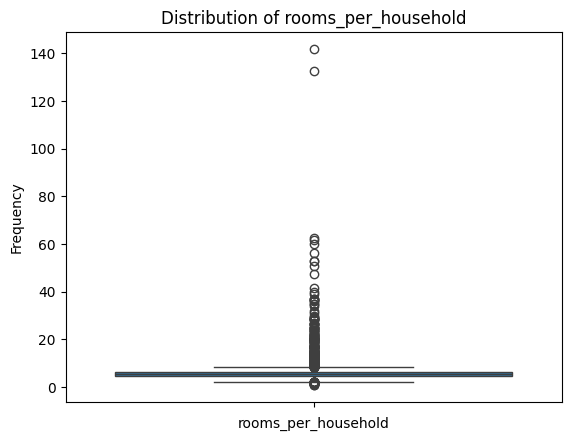

Column: bedrooms_per_household, Lower Bound: 0.87, Upper Bound: 1.24
count    20640.000000
mean         1.096832
std          0.473854
min          0.333333
25%          1.006508
50%          1.049084
75%          1.099192
max         34.066667
Name: bedrooms_per_household, dtype: float64
bedrooms_per_household: 6.02


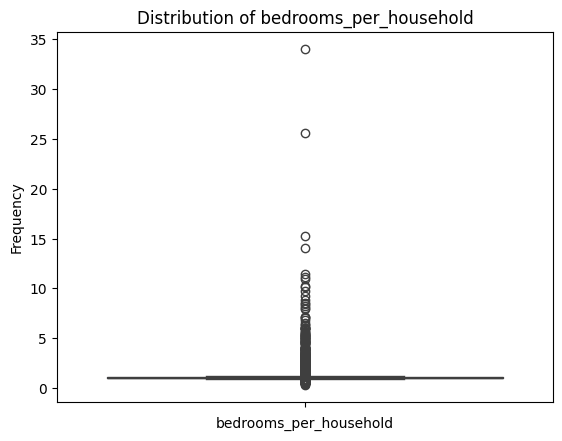

Column: population_per_household, Lower Bound: 1.15, Upper Bound: 4.56
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: population_per_household, dtype: float64
population_per_household: 3.41


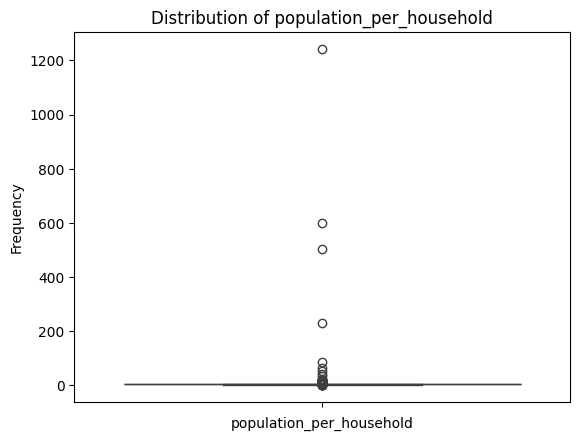

In [37]:
for col in log_transform_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    print(f"Column: {col}, Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
    print(df[col].describe())
    outliers_df = df[df[col] > upper_bound]
    print(f'{col}: {round(len(outliers_df) / len(df) * 100, 2)}')
    sns.boxplot(df[col])
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')
    plt.show()

In [38]:
from sklearn.model_selection import train_test_split, GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder,PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer,TransformedTargetRegressor
import shap
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.dummy import DummyRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score,root_mean_squared_error,root_mean_squared_log_error,mean_absolute_error
from sklearn.neighbors import BallTree
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from scipy.stats import shapiro
from statsmodels.stats.diagnostic import het_breuschpagan

In [39]:
df['lat_rad'] = np.radians(df['latitude'])
df['lon_rad'] = np.radians(df['longitude'])
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train = df_train.copy()
df_test = df_test.copy()

tree = BallTree(df_train[['lat_rad', 'lon_rad']].values, metric='haversine')
distances_train, indices_train = tree.query(df_train[['lat_rad', 'lon_rad']].values, k=6)
train_neighbor_prices = []
for i in range(len(df_train)):
    actual_neighbors = indices_train[i][1:]
    mean_price = df_train.iloc[actual_neighbors]['median_house_value'].mean()
    train_neighbor_prices.append(mean_price)

df_train['nearby_houses_average_price'] = train_neighbor_prices
distances_test, indices_test = tree.query(df_test[['lat_rad', 'lon_rad']].values, k=5)
test_neighbor_prices = []
for i in range(len(df_test)):
    actual_neighbors = indices_test[i]
    mean_price = df_train.iloc[actual_neighbors]['median_house_value'].mean()
    test_neighbor_prices.append(mean_price)

df_test['nearby_houses_average_price'] = test_neighbor_prices

In [40]:
x = df_train.drop(['median_house_value', 'latitude', 'longitude', 'lat_rad', 'lon_rad'], axis=1)
y = df_train['median_house_value']
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
dummy_regressor = DummyRegressor(strategy='mean')
dummy_regressor.fit(X_train, y_train)
print(f"Dummy Regressor Score: {dummy_regressor.score(X_test, y_test)}")

Dummy Regressor Score: -1.266980125258499e-07


In [41]:
X_mi = X_train.copy()

categorical_cols = X_mi.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    X_mi[col] = X_mi[col].astype('category').cat.codes

discrete_mask = X_train.columns.isin(categorical_cols)

mi_scores = mutual_info_regression(
    X_mi,
    y_train.astype('category').cat.codes,
    discrete_features=discrete_mask,
    random_state=42
)
mi_scores = pd.Series(mi_scores, index=X_train.columns)
mi_scores.sort_values(ascending=False, inplace=True)
mi_scores.head(20)

nearby_houses_average_price    1.010900
median_income                  0.377355
ocean_proximity                0.210293
bedrooms_per_room              0.138529
rooms_per_household            0.100614
population_per_household       0.069648
housing_median_age             0.042235
bedrooms_per_household         0.016114
dtype: float64

Training Linear Regression...


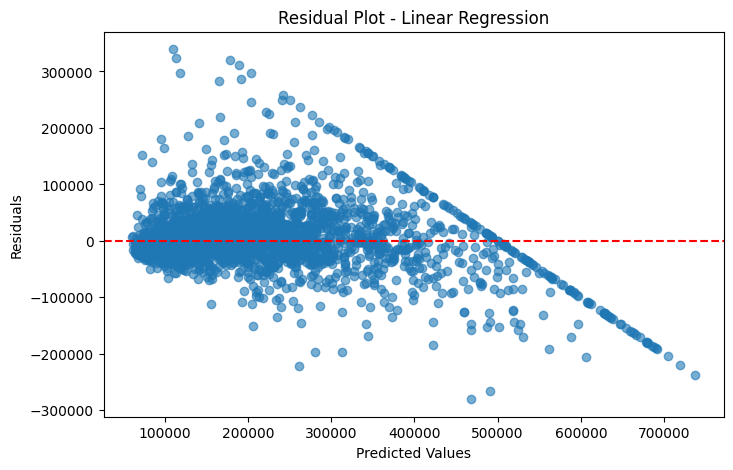

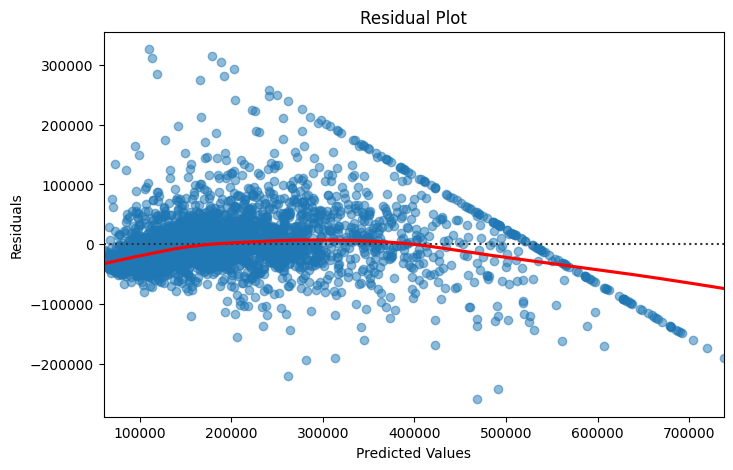

AttributeError: 'str' object has no attribute 'resid'

In [ ]:
log_transform_cols = list(set(log_transform_cols) & set(X_train.columns))

num_cols = X_train.select_dtypes(include=np.number).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

for col in log_transform_cols:
    if col in num_cols:
        num_cols.remove(col)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
log_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('power_transform', PowerTransformer(method='yeo-johnson')),
    ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols),
        ('log', log_transformer, log_transform_cols)
    ]
)


param_grid_LR = {
    'Regressor__fit_intercept': [True, False],
}
param_grid_Ridge = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__solver': ['auto','lsqr','sag'],
    'Regressor__fit_intercept': [True, False],
    'Regressor__copy_X': [True, False]
}
param_grid_Lasso = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__fit_intercept': [True, False],
    'Regressor__max_iter': [1000],
    'Regressor__copy_X': [True, False]
}
param_grid_ElasticNet = {
    'Regressor__alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'Regressor__l1_ratio': [0.1, 0.5, 0.9],
    'Regressor__fit_intercept': [True, False],
    'Regressor__max_iter': [1000],
    'Regressor__copy_X': [True, False]
}
param_grid_RF = {
    'Regressor__n_estimators': [100, 200],
    'Regressor__max_depth': [10, 12],
    'Regressor__min_samples_split': [5, 10],
    'Regressor__min_samples_leaf': [2, 4, 6],
    'Regressor__max_features': ['sqrt', 'log2'],
    'Regressor__bootstrap': [True, False]
}
param_grid_XGB = {
    'Regressor__n_estimators': [100, 300, 500],
    'Regressor__max_depth': [3, 6, 9],
    'Regressor__learning_rate': [0.01, 0.1, 0.2],
    'Regressor__subsample': [0.8, 1.0],
    'Regressor__colsample_bytree': [0.8, 1.0]
}
param_grid_LGBM = {
    'Regressor__n_estimators': [100, 300, 500],
    'Regressor__max_depth': [3, 6, 9],
    'Regressor__learning_rate': [0.01, 0.1, 0.2],
    'Regressor__subsample': [0.8, 1.0],
    'Regressor__num_leaves': [10, 20, 30],
    'Regressor__min_child_samples': [10, 20, 30],
    'Regressor__colsample_bytree': [0.8, 1.0],
}

models = {
    'Linear Regression': (
        TransformedTargetRegressor(
            regressor=LinearRegression(),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_LR
    ),

    'Ridge': (
        TransformedTargetRegressor(
            regressor=Ridge(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_Ridge
    ),

    'Lasso': (
        TransformedTargetRegressor(
            regressor=Lasso(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_Lasso
    ),

    'ElasticNet': (
        TransformedTargetRegressor(
            regressor=ElasticNet(random_state=42),
            transformer=PowerTransformer(method='yeo-johnson')
        ),
        param_grid_ElasticNet
    ),

    'Random Forest': (
        RandomForestRegressor(random_state=42),
        param_grid_RF
    ),

    'XGBoost': (
        XGBRegressor(
            random_state=42,
            eval_metric='rmse'
        ),
        param_grid_XGB
    ),

    'LightGBM': (
        LGBMRegressor(
            random_state=42,
            verbose=-1
        ),
        param_grid_LGBM
    )
}
linear_models = ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']
for m_name in linear_models:
    model_obj, p_grid = models[m_name]
    new_p_grid = {param.replace('Regressor__', 'Regressor__regressor__'): values for param, values in p_grid.items()}
    models[m_name] = (model_obj, new_p_grid)

all_models_results = []
saved_pipelines = {}
best_R2_score = -1
best_pipeline = None
for model_name, (model, param_grid) in models.items():
    print(f"Training {model_name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('Regressor', model)])

    if model_name in ['Linear Regression', 'Ridge', 'Lasso', 'ElasticNet']:
        grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
    else:
        grid_search = RandomizedSearchCV(pipeline, param_distributions=param_grid, n_iter=75, cv=5, scoring='r2', n_jobs=-1, random_state=42)

    grid_search.fit(X_train, y_train)

    y_pred_train = grid_search.predict(X_train)
    y_pred_test = grid_search.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    if (y_test >= 0).all() and (y_pred_test >= 0).all():
      rmsle_val = root_mean_squared_log_error(
        y_test,
        y_pred_test
    )
    else:
      rmsle_val = np.nan


    all_models_results.append({
        'Model Name': model_name,
        'r2 score_train': r2_train,
        'r2 score_test': r2_test,
        'Overfitting Gap': r2_train - r2_test,
        'root_mean_squared_error': root_mean_squared_error(y_test, y_pred_test),
        'mean_absolute_error': mean_absolute_error(y_test, y_pred_test),
        'root_mean_squared_log_error': rmsle_val
    })
    saved_pipelines[model_name] = grid_search.best_estimator_
    if r2_test > best_R2_score:
        best_R2_score = r2_test
        best_pipeline = grid_search.best_estimator_


    plt.figure(figsize=(6,6))
    plt.scatter(y_test, y_pred_test, alpha=0.6)
    plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
    )
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted - {model_name}")
    plt.show()


    residuals = y_test - y_pred_test
    print(f"Residual Mean: {residuals.mean():.4f}")
    print(f"Residual Std : {residuals.std():.4f}")

    plt.figure(figsize=(8,5))
    plt.scatter(
    y_test,
    y_pred_test,
    alpha=0.6,
    edgecolors='k'
    )
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Predicted Values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot - {model_name}")
    plt.show() 

    plt.figure(figsize=(8,5))
    sns.histplot(residuals, kde=True)
    plt.xlabel("Residuals")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of Residuals - {model_name}")
    plt.show()

    
    sm.qqplot(residuals,line='45')
    plt.title(f"Normal Q-Q Plot - {model_name}")
    plt.show()
   
    dw_value = durbin_watson(residuals)
    print(f"Durbin-Watson Statistic: {dw_value:.4f}")
    if 1.5 <= dw_value <= 2.5:
      print("No significant autocorrelation detected.")
    elif dw_value < 1.5:
      print("Positive autocorrelation detected.")
    else:
      print("Negative autocorrelation detected.")


    
    stat, p_value = shapiro(residuals)
    print(f"Shapiro Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.4f}")
    if p_value > 0.05:
        print("Residuals appear normally distributed.")
    else:
        print("Residuals deviate from normality.")


report_df = pd.DataFrame(all_models_results).sort_values('r2 score_test', ascending=False)
report_df

In [ ]:
top_models = [
    'Random Forest',
    'XGBoost',
    'LightGBM'
]



y_pred_train_all = []
y_pred_test_all = []

for model_name in top_models:

    pipeline = saved_pipelines[model_name]

    y_pred_train_all.append(
        pipeline.predict(X_train)
    )

    y_pred_test_all.append(
        pipeline.predict(X_test)
    )



y_pred_train_v = np.mean(y_pred_train_all, axis=0)
y_pred_test_v = np.mean(y_pred_test_all, axis=0)



R2_train_v = r2_score(y_train, y_pred_train_v)
R2_test_v = r2_score(y_test, y_pred_test_v)

rmse_v = root_mean_squared_error(
    y_test,
    y_pred_test_v
)

mae_v = mean_absolute_error(
    y_test,
    y_pred_test_v
)

if (y_test >= 0).all() and (y_pred_test_v >= 0).all():
    rmsle_v = root_mean_squared_log_error(
        y_test,
        y_pred_test_v
    )
else:
    rmsle_v = np.nan

all_models_results.append({
    'Model Name': 'Voting Regressor',
    'r2 score_train': R2_train_v,
    'r2 score_test': R2_test_v,
    'Overfitting Gap': R2_train_v - R2_test_v,
    'root_mean_squared_error': rmse_v,
    'mean_absolute_error': mae_v,
    'root_mean_squared_log_error': rmsle_v
})
report_df = pd.DataFrame(all_models_results).sort_values('r2 score_test', ascending=False)
report_df

,Model Name,r2 score_train,r2 score_test,Overfitting Gap,root_mean_squared_error,mean_absolute_error,root_mean_squared_log_error
7,Voting Regressor,0.922034,0.864241,0.057792,42065.144389,26906.630656,0.202559
4,Random Forest,0.948932,0.864069,0.084864,42091.886259,27161.719272,0.203818
5,XGBoost,0.909356,0.862228,0.047128,42375.955761,27026.120493,0.203591
6,LightGBM,0.898099,0.861668,0.036431,42461.866154,27097.076177,0.203960
3,ElasticNet,0.811554,0.806063,0.005491,50276.969608,32953.208876,0.236626
1,Ridge,0.800758,0.798769,0.001989,51213.707532,32708.689689,0.230350
0,Linear Regression,0.799188,0.797876,0.001312,51327.160098,32741.241275,0.230057
2,Lasso,0.799589,0.797577,0.002011,51365.075380,32898.529720,0.231282


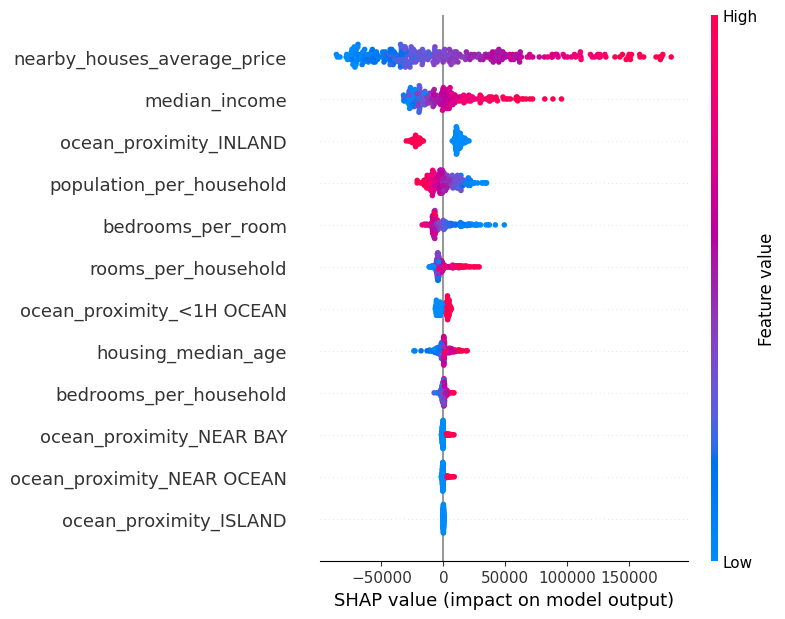

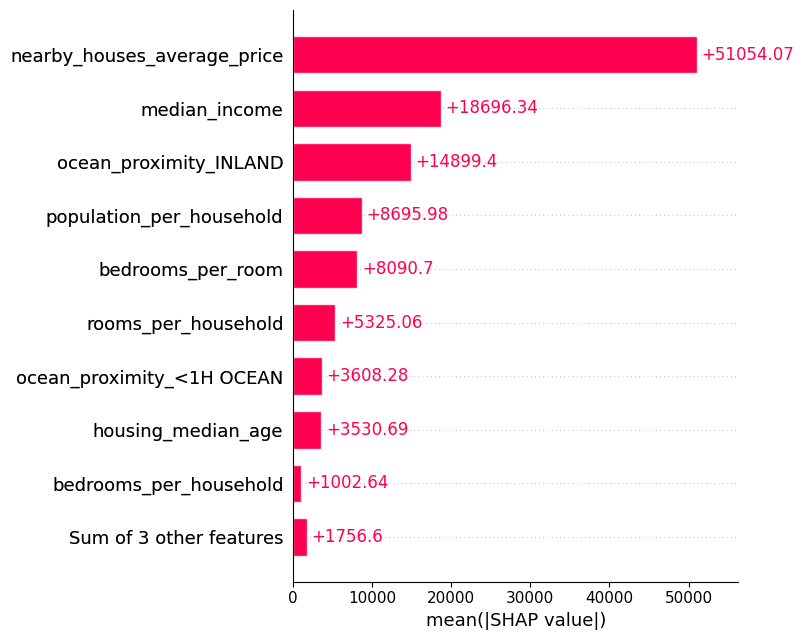

In [ ]:
best_model_step = best_pipeline.named_steps['Regressor']
preprocessor_step = best_pipeline.named_steps['preprocessor']

X_test_transformed = preprocessor_step.transform(X_test)

if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()


try:
    feature_names = preprocessor_step.get_feature_names_out()
    feature_names = [name.split('__')[-1] for name in feature_names]
except:
    feature_names = []
    for name, transformer, columns in preprocessor_step.transformers_:
        if name == 'remainder' and transformer == 'drop':
            continue

        if hasattr(transformer, 'get_feature_names_out'):
            try:
                feature_names.extend(transformer.get_feature_names_out(columns))
            except:
                feature_names.extend(columns)
        else:
            feature_names.extend(columns)

    feature_names = [name.split('__')[-1] for name in feature_names]

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)


SHAP_SAMPLE_SIZE = min(300, len(X_test_transformed_df))

X_shap_input = X_test_transformed_df.sample(
    n=SHAP_SAMPLE_SIZE,
    random_state=42
)


model_name = type(best_model_step).__name__

if model_name == "TransformedTargetRegressor":

    actual_model = best_model_step.regressor

    explainer = shap.LinearExplainer(
        actual_model,
        X_shap_input
    )

    shap_values = explainer(X_shap_input)

elif model_name in [
    "RandomForestRegressor",
    "XGBRegressor",
    "LGBMRegressor"
]:

    explainer = shap.TreeExplainer(best_model_step)

    shap_values = explainer(X_shap_input)

else:

    explainer = shap.LinearExplainer(
        best_model_step,
        X_shap_input
    )

    shap_values = explainer(X_shap_input)


plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values.values if hasattr(shap_values, "values") else shap_values,
    X_shap_input,
    show=False
)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

shap.plots.bar(
    shap_values,
    show=False
)

plt.tight_layout()
plt.show()

In [ ]:
report_df.to_csv('House_models_comparison_leaderboard.csv', index=False)
print("Leaderboard saved successfully!")

Leaderboard saved successfully!
